In [1]:
# ============================================
# LIBRERÍAS REQUERIDAS
# ============================================
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ============================================
# 1. CARGAR DATOS
# ============================================
# Cargar dataset de retail online (con encoding específico)
df = pd.read_csv("./data/online+retail/onlineRetail.csv", encoding="ISO-8859-1")

print("\n=== PRIMERAS FILAS ===\n")
print(df.head())


=== PRIMERAS FILAS ===

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [3]:
# Información de estructura
print("\n=== ESTRUCTURA DEL DATASET ===\n")
print(df.info())


=== ESTRUCTURA DEL DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


In [4]:
# ============================================
# 2. LIMPIEZA DE DATOS
# ============================================
# Eliminar registros con CustomerID nulos
df = df.dropna(subset=["CustomerID"])

# Eliminar cancelaciones (facturas empezando con 'C')
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Eliminar cantidades negativas o cero (devoluciones/errores)
df = df[df["Quantity"] > 0]

# Eliminar precios negativos o cero (devoluciones/errores)
df = df[df["UnitPrice"] > 0]

# Convertir tipos de datos
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])  # datetime
df["CustomerID"] = df["CustomerID"].astype(int)  # entero

In [5]:
# Estadísticas básicas
print("\n=== RESUMEN DE DATOS LIMPIOS ===\n")
print(f"Registros (líneas de venta): {df.shape[0]:,}")
print(f"Clientes únicos: {df['CustomerID'].nunique():,}")
print(f"Pedidos únicos: {df['InvoiceNo'].nunique():,}")


=== RESUMEN DE DATOS LIMPIOS ===

Registros (líneas de venta): 397,884
Clientes únicos: 4,338
Pedidos únicos: 18,532


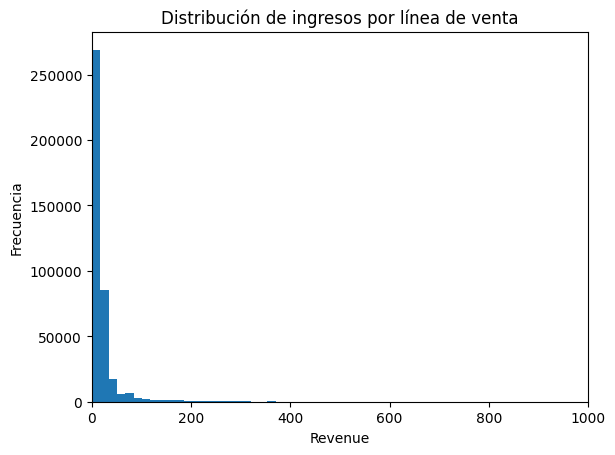

In [6]:
# ============================================
# 3. ANÁLISIS DE INGRESOS
# ============================================
# Calcular revenue por línea de venta
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Visualización: Distribución de ingresos por línea
plt.figure()
plt.hist(df["Revenue"], bins=10000)
plt.title("Distribución de ingresos por línea de venta")
plt.xlabel("Revenue")
plt.ylabel("Frecuencia")
plt.xlim(0, 1000)  # Limitar eje x para mejor visualización
plt.show()

In [7]:
# Estadísticas descriptivas de revenue
print("\n=== ESTADÍSTICAS DE REVENUE POR LÍNEA ===\n")
print(df["Revenue"].describe())


=== ESTADÍSTICAS DE REVENUE POR LÍNEA ===

count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64


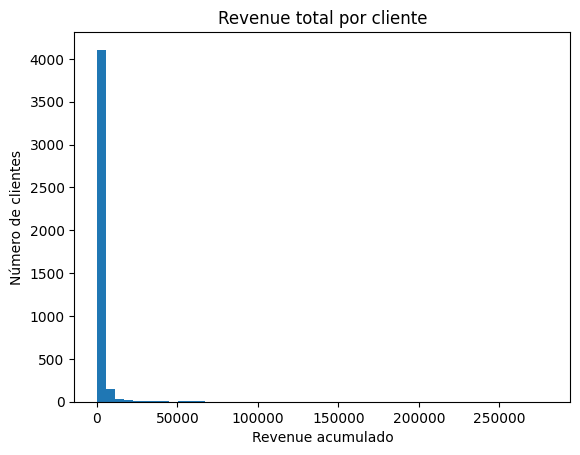

In [8]:
# Análisis: Gasto total por cliente
revenue_customer = df.groupby("CustomerID")["Revenue"].sum()

# Visualización: Distribución de revenue por cliente
plt.figure()
plt.hist(revenue_customer, bins=50)
plt.title("Revenue total por cliente")
plt.xlabel("Revenue acumulado")
plt.ylabel("Número de clientes")
plt.show()

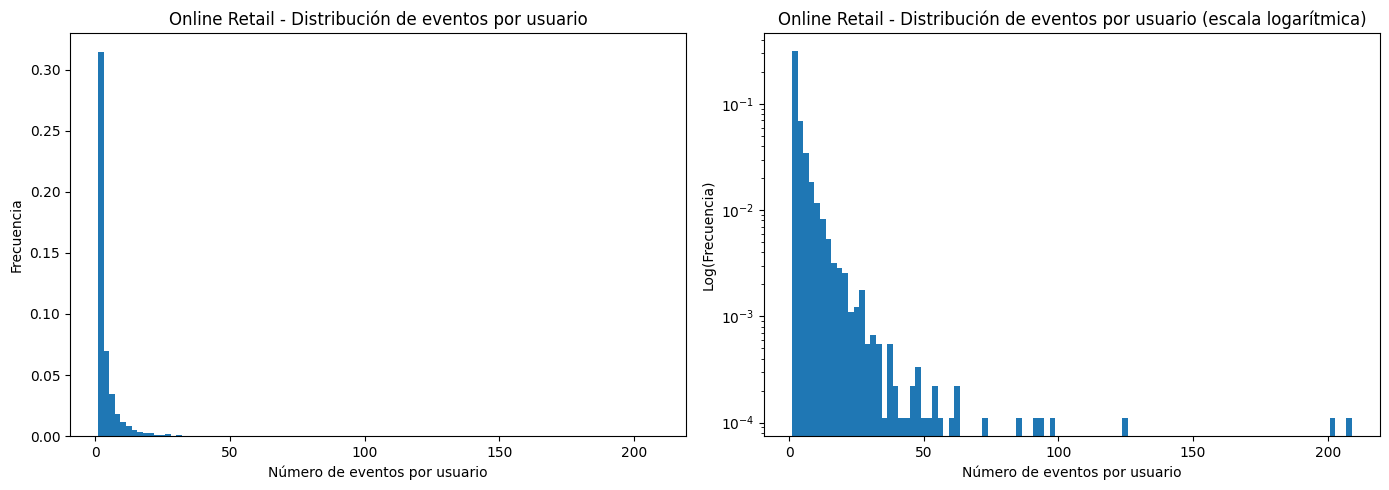

In [9]:
# ============================================
# 4. ANÁLISIS DE FRECUENCIA DE COMPRA
# ============================================
# Contar número de pedidos por cliente
frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()

# Visualización: Histograma de eventos por usuario
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Primer gráfico - escala lineal
ax1.hist(frequency, bins=100, density=True)
ax1.set_title("Online Retail - Distribución de eventos por usuario")
ax1.set_xlabel("Número de eventos por usuario")
ax1.set_ylabel("Frecuencia")

# Segundo gráfico - escala logarítmica
ax2.hist(frequency, bins=100, density=True, log=True)
ax2.set_title("Online Retail - Distribución de eventos por usuario (escala logarítmica)")
ax2.set_xlabel("Número de eventos por usuario")
ax2.set_ylabel("Log(Frecuencia)")

plt.tight_layout()
plt.show()

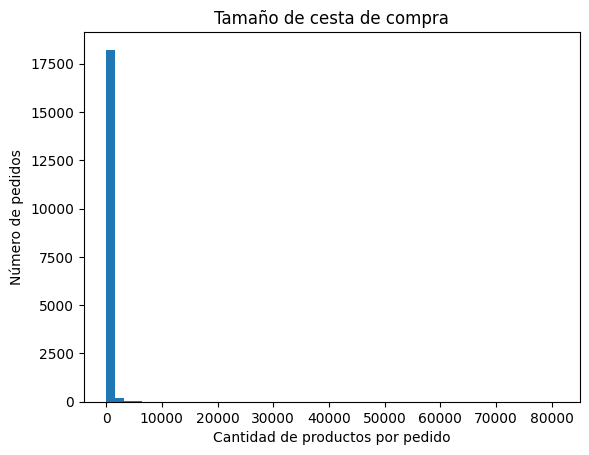

In [10]:
# ============================================
# 5. ANÁLISIS DE TAMAÑO DE CESTA
# ============================================
# Calcular cantidad total de productos por pedido
basket_size = df.groupby("InvoiceNo")["Quantity"].sum()

# Visualización: Distribución de tamaño de cesta
plt.figure()
plt.hist(basket_size, bins=50)
plt.title("Tamaño de cesta de compra")
plt.xlabel("Cantidad de productos por pedido")
plt.ylabel("Número de pedidos")
plt.show()

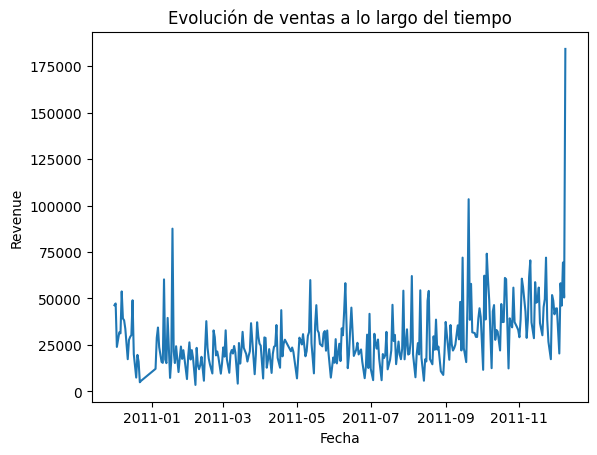

In [11]:
# ============================================
# 6. ANÁLISIS TEMPORAL - VENTAS POR FECHA
# ============================================
# Extraer fecha y agrupar ventas
df["date"] = df["InvoiceDate"].dt.date
sales_time = df.groupby("date")["Revenue"].sum()

# Visualización: Evolución de ventas a lo largo del tiempo
plt.figure()
sales_time.plot()
plt.title("Evolución de ventas a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("Revenue")
plt.show()

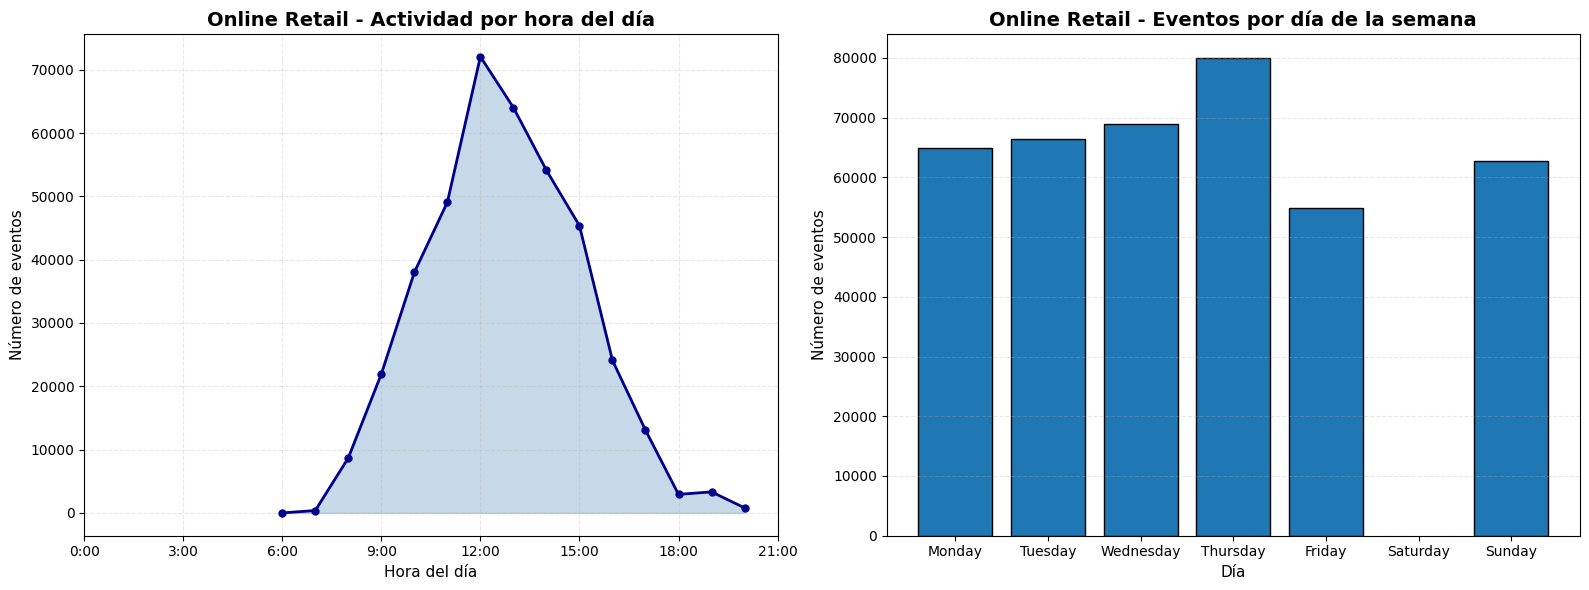


=== ESTADÍSTICAS DE ACTIVIDAD ===

Hora pico: 12 (72,065 eventos)
Hora valle: 6 (1 eventos)
Día más activo: Thursday (80,035.0 eventos)
Día menos activo: Friday (54,825.0 eventos)


In [12]:
# ============================================
# 7. ANÁLISIS TEMPORAL - VENTAS POR HORA
# ============================================

# Datos por hora
df["hour"] = df["InvoiceDate"].dt.hour
events_hour = df.groupby("hour").size()

# Datos por día de la semana
df["weekday"] = df["InvoiceDate"].dt.day_name()
weekday_events = df.groupby("weekday").size()
weekday_events = weekday_events.reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])

# ============================================
# GRÁFICOS LADO A LADO - VERSIÓN MEJORADA
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Actividad por hora (área rellena)
ax1.fill_between(events_hour.index, events_hour.values, alpha=0.3, color='steelblue')
ax1.plot(events_hour.index, events_hour.values, marker='o', linewidth=2, markersize=5, color='darkblue')
ax1.set_title("Online Retail - Actividad por hora del día", fontsize=14, fontweight='bold')
ax1.set_xlabel("Hora del día", fontsize=11)
ax1.set_ylabel("Número de eventos", fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(range(0, 24, 3))  # Mostrar cada 3 horas: 0, 3, 6, ..., 21
ax1.set_xticklabels([f"{h}:00" for h in range(0, 24, 3)])

# Gráfico 2: Eventos por día de la semana
bars = ax2.bar(weekday_events.index, weekday_events.values,  edgecolor='black', linewidth=1)
ax2.set_title("Online Retail - Eventos por día de la semana", fontsize=14, fontweight='bold')
ax2.set_xlabel("Día", fontsize=11)
ax2.set_ylabel("Número de eventos", fontsize=11)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')


plt.tight_layout()
plt.show()

# ============================================
# ESTADÍSTICAS ADICIONALES (opcional)
# ============================================
print("\n=== ESTADÍSTICAS DE ACTIVIDAD ===\n")
print(f"Hora pico: {events_hour.idxmax()} ({events_hour.max():,} eventos)")
print(f"Hora valle: {events_hour.idxmin()} ({events_hour.min():,} eventos)")
print(f"Día más activo: {weekday_events.idxmax()} ({weekday_events.max():,} eventos)")
print(f"Día menos activo: {weekday_events.idxmin()} ({weekday_events.min():,} eventos)")

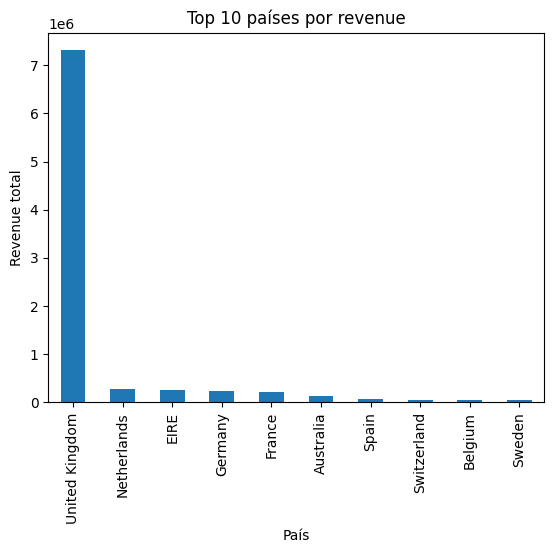

In [13]:
# ============================================
# 8. ANÁLISIS GEOGRÁFICO - TOP PAÍSES
# ============================================
# Agrupar revenue por país
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

# Visualización: Top 10 países por revenue
plt.figure()
country_sales.head(10).plot(kind="bar")
plt.title("Top 10 países por revenue")
plt.xlabel("País")
plt.ylabel("Revenue total")
plt.show()

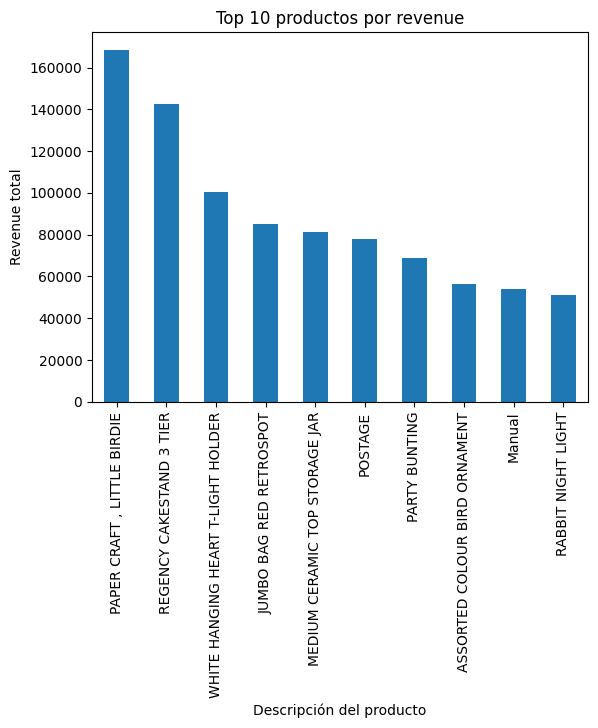

In [14]:
# ============================================
# 9. ANÁLISIS DE PRODUCTOS
# ============================================
# Agrupar revenue por descripción de producto
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False)

# Visualización: Top 10 productos por revenue
plt.figure()
top_products.head(10).plot(kind="bar")
plt.title("Top 10 productos por revenue")
plt.xlabel("Descripción del producto")
plt.ylabel("Revenue total")
plt.show()

In [15]:
# ============================================
# 10. SEGMENTACIÓN RFM (RECENCY, FREQUENCY, MONETARY)
# ============================================
# Definir fecha de snapshot (última fecha del dataset)
snapshot_date = df["InvoiceDate"].max()

In [16]:
# Calcular métricas RFM por cliente
# Recency: días desde última compra
# Frequency: número de compras
# Monetary: gasto total
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency (días)
    "InvoiceNo": "nunique",  # Frequency (compras)
    "Revenue": "sum"  # Monetary (gasto)
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

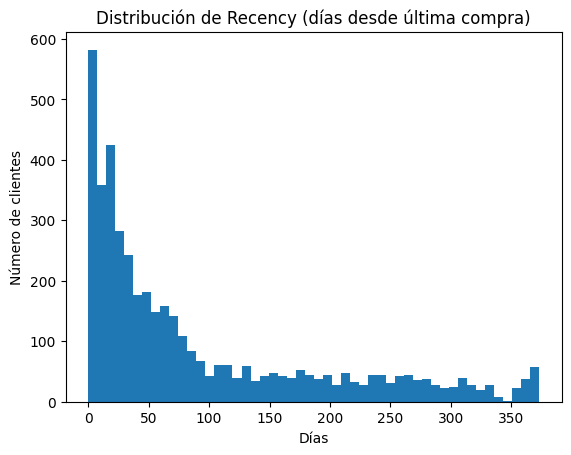

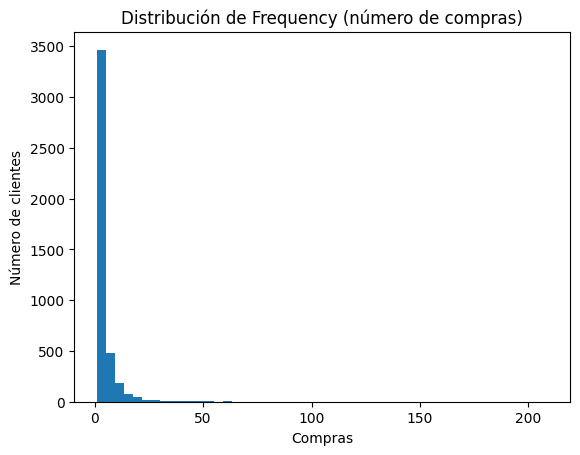

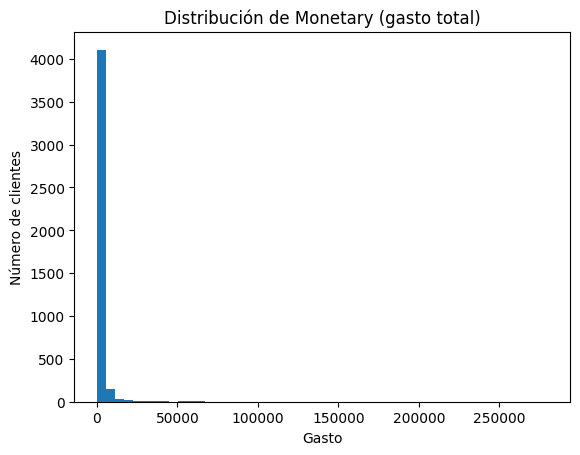

In [17]:
# Visualización: Distribuciones RFM
plt.figure()
plt.hist(rfm["Recency"], bins=50)
plt.title("Distribución de Recency (días desde última compra)")
plt.xlabel("Días")
plt.ylabel("Número de clientes")
plt.show()

plt.figure()
plt.hist(rfm["Frequency"], bins=50)
plt.title("Distribución de Frequency (número de compras)")
plt.xlabel("Compras")
plt.ylabel("Número de clientes")
plt.show()

plt.figure()
plt.hist(rfm["Monetary"], bins=50)
plt.title("Distribución de Monetary (gasto total)")
plt.xlabel("Gasto")
plt.ylabel("Número de clientes")
plt.show()

In [18]:
# ============================================
# 11. SCORING RFM
# ============================================
# Crear scores (1-4) para cada métrica
# Recency: Menor recency = Mayor score (cliente reciente)
# Frequency: Mayor frequency = Mayor score (cliente frecuente)
# Monetary: Mayor monetary = Mayor score (cliente de alto valor)

rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1])  # Invertido
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1, 2, 3, 4])

# Score RFM total (suma de los tres scores)
rfm["RFM_score"] = rfm[["R_score", "F_score", "M_score"]].sum(axis=1)

In [19]:
# Muestra de 10 clientes aleatorios con sus scores RFM
print("\n=== MUESTRA ALEATORIA DE CLIENTES CON SCORES RFM ===\n")
print(rfm.sample(10))


=== MUESTRA ALEATORIA DE CLIENTES CON SCORES RFM ===

            Recency  Frequency  Monetary R_score F_score M_score  RFM_score
CustomerID                                                                 
17026           184          2    154.83       1       2       1          4
15453             1          7   1388.37       4       4       3         11
12758           116          2   2791.59       2       2       4          8
14834            17          6   1720.30       4       4       4         12
15065            37          4   3158.13       3       3       4         10
15454           361          1    179.10       1       1       1          3
13338           157          1    487.02       1       1       2          4
13344            67          3   2543.72       2       3       4          9
14431           302          1    470.36       1       1       2          4
17891           161          1    203.86       1       2       1          4


In [20]:
# Top 10 clientes por gasto (Monetary)
print("\n=== TOP 10 CLIENTES POR GASTO (VALOR MONETARIO) ===\n")
print(rfm.sort_values(by=['Monetary'], ascending=False).head(10))


=== TOP 10 CLIENTES POR GASTO (VALOR MONETARIO) ===

            Recency  Frequency   Monetary R_score F_score M_score  RFM_score
CustomerID                                                                  
14646             1         73  280206.02       4       4       4         12
18102             0         60  259657.30       4       4       4         12
17450             7         46  194550.79       4       4       4         12
16446             0          2  168472.50       4       2       4         10
14911             0        201  143825.06       4       4       4         12
12415            23         21  124914.53       3       4       4         11
14156             9         55  117379.63       4       4       4         12
17511             2         31   91062.38       4       4       4         12
16029            38         63   81024.84       3       4       4         11
12346           325          1   77183.60       1       1       4          6
